## Channel storage and discharge experiments

This notebook tests BMI state editing in PCR-GLOBWB.

Main question:
- What happens when `channel_storage` is changed through `set_value`?


Workflow:
- Build the model setup and forcing objects.
- Run a baseline `get_value` experiment.
- Run a `set_value(channel_storage)` experiment.
- Compare model output and observations.

The commented cells near the end are historical experiments kept as reference.

In [ ]:
# Docker/apptainer build steps used for the image test.
# docker build -t ewatercycle-pcr-17feb .
# docker save -o ewatercycle_pcr_17feb.tar ewatercycle-pcr-17feb
# apptainer build ewatercycle_pcr_17feb.sif docker-archive://ewatercycle_pcr_17feb.tar

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from rich import print
from tqdm.notebook import tqdm

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage

PROJECT_ROOT = Path().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
STATIONS_PCR

{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.3},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Uch-Kurgan': {'lat': 41.12, 'lon': 72.1},
 'Garm': {'lat': 39.05, 'lon': 70.33}}

In [3]:
pcr_glob_directory = PCR_GLOBAL_PARAMS
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL

parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "calibrated_best_save.ini",
    target_model="pcrglobwb",
    supported_model_versions={"25mar"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [4]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_25mar.sif")
my_image.version

'25mar'

In [5]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

reference_2x = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/ini_files/calibrated_best_save.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'25mar'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1940-01-01T00:00:00Z',
        end_time='1960-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
    )
)

In [6]:
experiment_start_date = "1950-06-01T00:00:00Z"
experiment_end_date = "1950-07-30T00:00:00Z"

In [7]:
from pathlib import Path
import shutil

for cfg_dir in [Path("channel_experiment_reference"), Path("channel_experiment_set_storage")]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_reference"
)
reference_config, reference_dir

reference_2x_config, reference_2x_dir = reference_2x.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_set_storage"
)
reference_2x_config, reference_2x_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/irrigation_experiments/channel_experiment_set_storage/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/irrigation_experiments/channel_experiment_set_storage')

In [8]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-06-01T00:00:00Z'), ('end_time', '1950-07-30T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 59

In [9]:
reference.initialize(reference_config)
reference_2x.initialize(reference_2x_config)

In [10]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
stations_timeseries.head()

stations_timeseries_getvalue = stations_timeseries.copy()
stations_timeseries_setvalue = stations_timeseries.copy()
stations_timeseries_setvalue_before = stations_timeseries.copy()
stations_timeseries_reference = stations_timeseries.copy()

channel_storage_getvalue_series = stations_timeseries.copy()
channel_storage_setvalue_before_update_series = stations_timeseries.copy()
channel_storage_setvalue_series = stations_timeseries.copy()

In [11]:
lat_idx = 61
lon_idx = 127

for _ in tqdm(range(number_of_days), desc="Running model"):
    reference.update()
    reference_2x.update()

    # Perturb one cell in channel storage after the update.
    test_variable = reference_2x.get_value_as_xarray("channel_storage")
    test_values = test_variable.values.copy()
    test_values[lat_idx, lon_idx] += 1e8
    reference_2x.set_value("channel_storage", test_values.flatten())

print("Model run finished!")

Running model:   0%|          | 0/59 [00:00<?, ?it/s]

Model run finished!

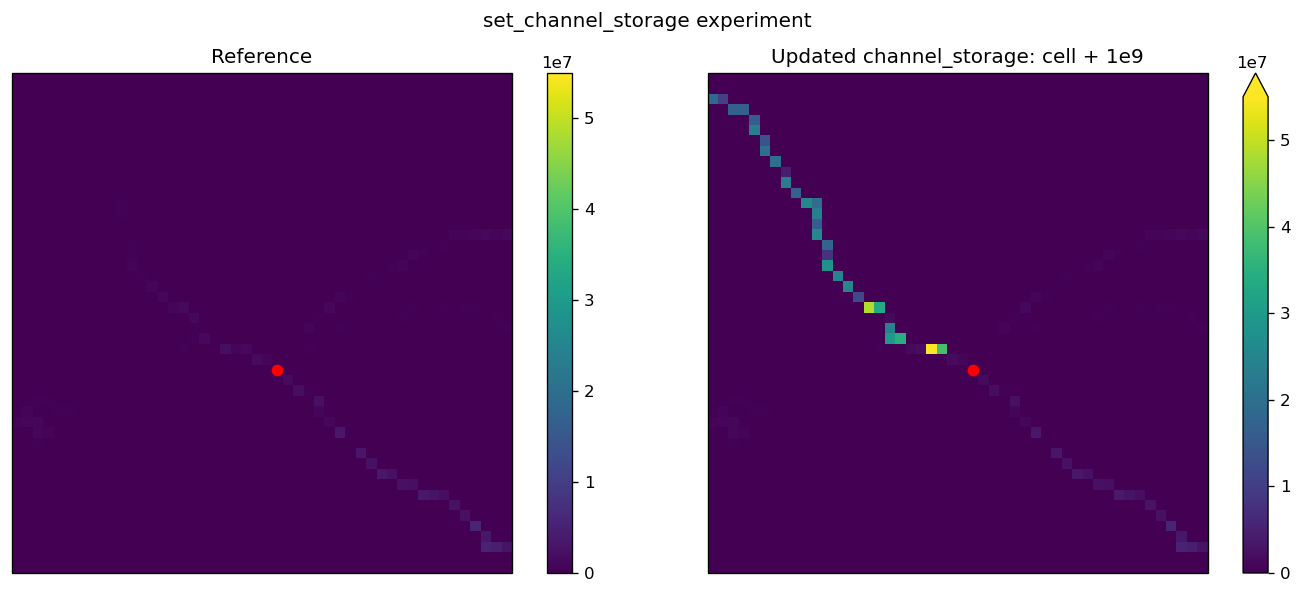

In [12]:
discharge_getvalue_plot = reference.get_value_as_xarray("channel_storage")
discharge_setvalue_plot = reference_2x.get_value_as_xarray("channel_storage")


# -----------------------------
# Replace non-positive values
# -----------------------------
discharge_getvalue_plot_safe = discharge_getvalue_plot.where(discharge_getvalue_plot > 0, 1e-6)
discharge_setvalue_plot_safe = discharge_setvalue_plot.where(discharge_setvalue_plot > 0, 1e-6)

# Swap coordinates names
discharge_getvalue_plot_safe = discharge_getvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

discharge_setvalue_plot_safe = discharge_setvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

vmin_plot = 1
# -----------------------------
# Define zoom box (lon/lat)
# -----------------------------
lon_min, lon_max = 61.5, 65.5
lat_min, lat_max = 37.5, 41.5

# Ensure correct slicing even if coordinates are descending
lat0, lat1 = sorted([lat_min, lat_max])
lon0, lon1 = sorted([lon_min, lon_max])

get_value_subset = discharge_getvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

set_value_subset = discharge_setvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

# -----------------------------
# Set up figure
# -----------------------------
fig = plt.figure(figsize=(12, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=ccrs.PlateCarree())
right_axes = fig.add_subplot(122, projection=ccrs.PlateCarree())

# -----------------------------
# Plot the subsets
# -----------------------------
get_value_subset.plot(
    ax=left_axes,
    x="longitude",
    y="latitude",
    cmap="viridis",
    vmax=5.5e7,
    # norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max())
)

set_value_subset.plot(
    ax=right_axes,
    x="longitude",
    y="latitude",
    cmap="viridis",
    vmax=5.5e7,
    # norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max())
)

# -----------------------------
# Decorations
# -----------------------------
left_axes.set_title("Reference")
right_axes.set_title("Updated channel_storage: cell + 1e9")

for ax in [left_axes, right_axes]:
    ax.add_feature(cfeature.OCEAN, zorder=2)
    ax.coastlines(zorder=3)

# -----------------------------
# Plot a point
# -----------------------------
point_lon, point_lat = 63.62, 39.122
for ax in [left_axes, right_axes]:
    ax.plot(
        point_lon, point_lat, color="red", linewidth=3, marker="o", transform=ccrs.PlateCarree()
    )

plt.suptitle("set_channel_storage experiment")
plt.tight_layout()
plt.show()

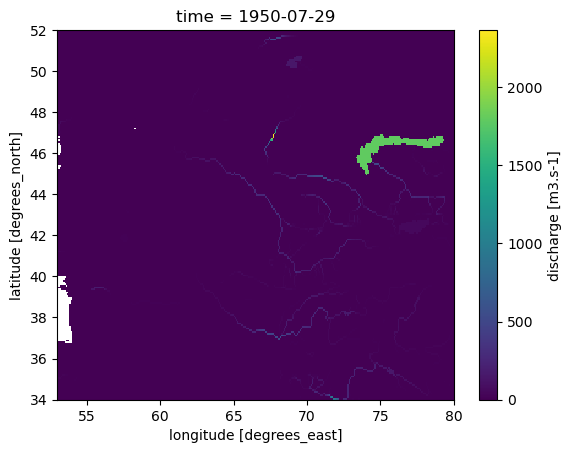

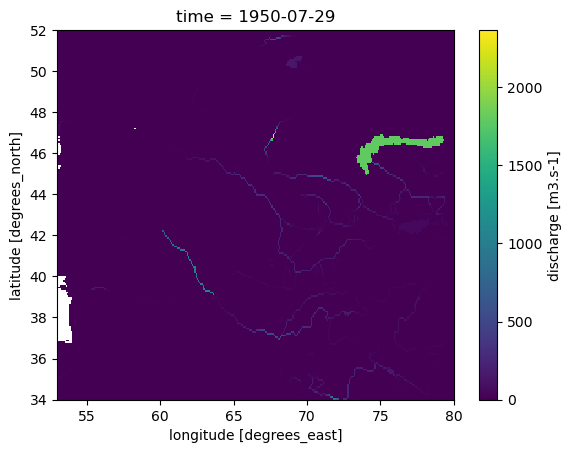

In [13]:
path_2 = "channel_experiment_set_storage/netcdf/discharge_dailyTot_output.nc"
path_1 = "channel_experiment_reference/netcdf/discharge_dailyTot_output.nc"

import xarray as xr

ds_ref = xr.open_dataset(path_1)
ds_update = xr.open_dataset(path_2)


var_ref = ds_ref["discharge"]
var_update = ds_update["discharge"]

plt.figure()
var_ref.isel(time=-1).plot()

plt.figure()
var_update.isel(time=-1).plot()

1950-07-29

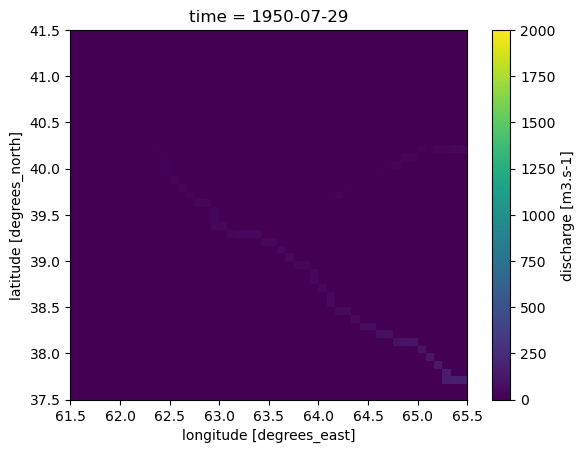

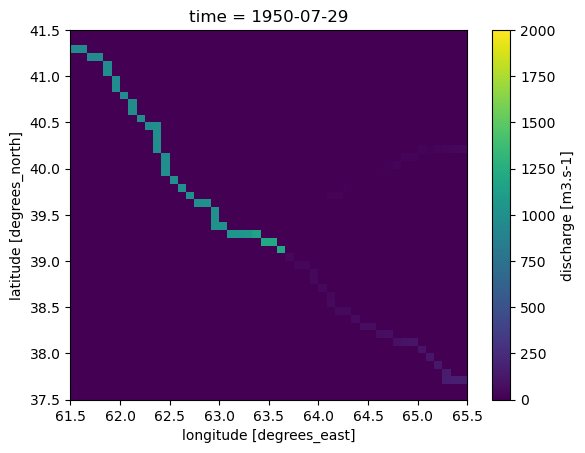

In [14]:
plot_date   = (pd.to_datetime('1950-07-30T00:00:00Z') - pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(plot_date)  # Output: 1950-07-29



subset_ref = ds_ref["discharge"].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # reversed because lat is descending
)

subset_update = ds_update["discharge"].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # reversed because lat is descending
)


plt.figure()
subset_ref.sel(time=plot_date).plot(vmax=2000)

plt.figure()
subset_update.sel(time=plot_date).plot(vmax=2000)

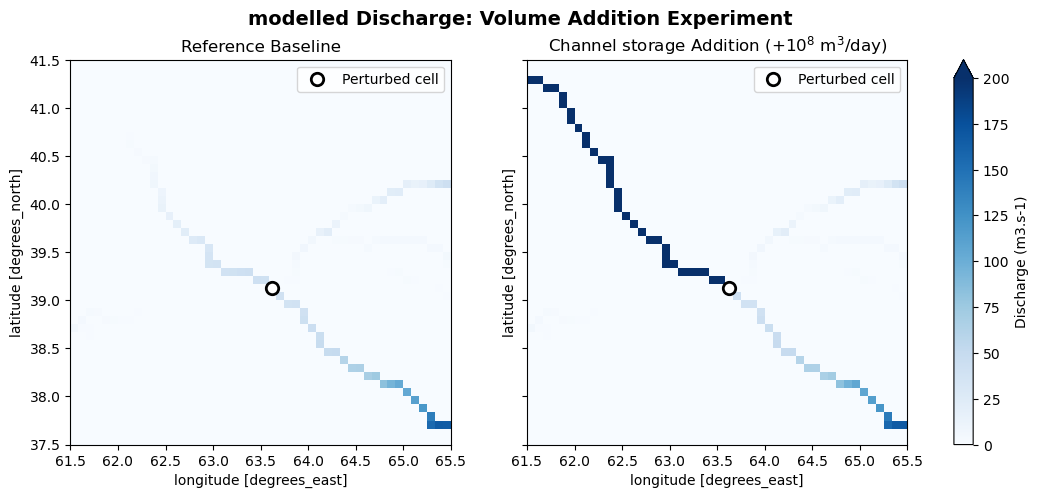

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

vmax = 200
vmin = 0



im = subset_ref.sel(time=plot_date).plot(
    ax=axes[0], vmin=vmin, vmax=vmax, add_colorbar=False, cmap="Blues"
)
axes[0].set_title("Reference Baseline")

subset_update.sel(time=plot_date).plot(
    ax=axes[1], vmin=vmin, vmax=vmax, add_colorbar=False, cmap="Blues"
)
axes[1].set_title(r"Channel storage Addition ($+10^8\text{ m}^3/\text{day}$)", fontsize=12)

point_lon, point_lat = 63.62, 39.122
for ax in axes:
    #ax.scatter(point_lon, point_lat, color="black", s=60, marker="o", zorder=5)
    ax.scatter(point_lon, point_lat, facecolors="white", edgecolors="black", linewidths=2, s=80, marker="o", zorder=5, label="Perturbed cell")
    ax.legend()

cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.05, extend="max")

# ---- Add label manually ----
units = subset_ref.attrs.get("units", "")
cbar.set_label(f"Discharge ({units})")
#plt.suptitle("set_channel_storage experiment: modelled Discharge")
plt.suptitle("modelled Discharge: Volume Addition Experiment",fontsize=14, fontweight="bold", y=0.98)
# plt.tight_layout()
plt.savefig("channel_storage_experiment_discharge_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

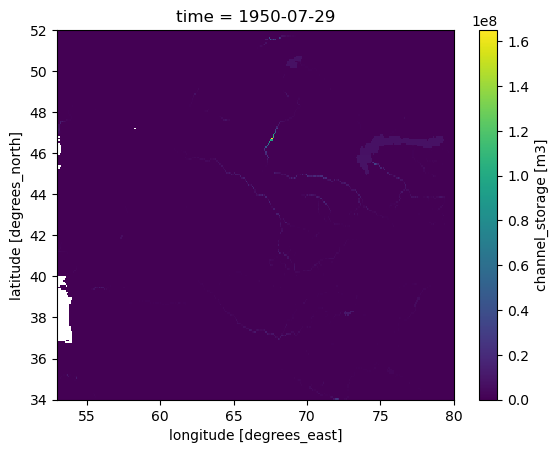

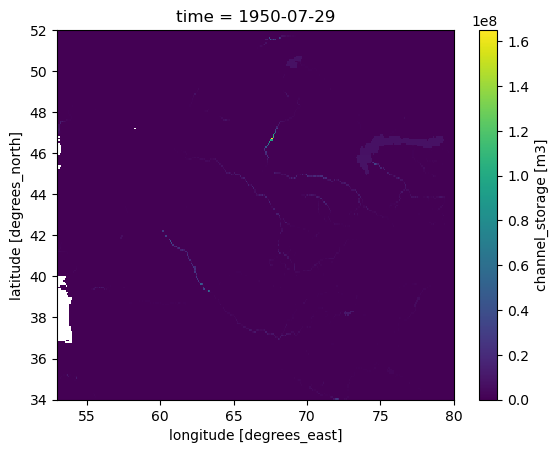

In [16]:
path_2a = "channel_experiment_set_storage/netcdf/channelStorage_dailyTot_output.nc"
path_1a = "channel_experiment_reference/netcdf/channelStorage_dailyTot_output.nc"

import xarray as xr

ds_ref = xr.open_dataset(path_1a)
ds_update = xr.open_dataset(path_2a)


var_ref = ds_ref["channel_storage"]
var_update = ds_update["channel_storage"]

plt.figure()
var_ref.isel(time=-1).plot()

plt.figure()
var_update.isel(time=-1).plot()

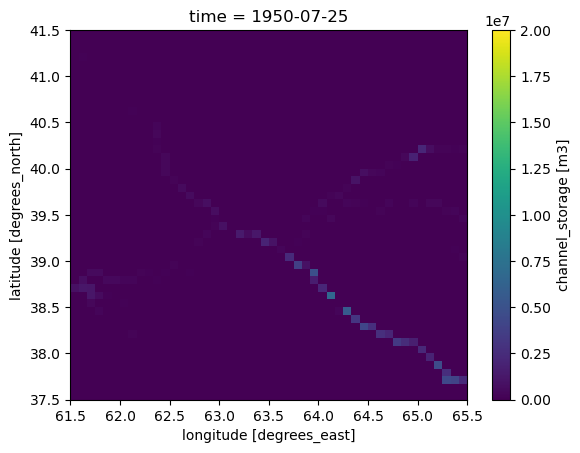

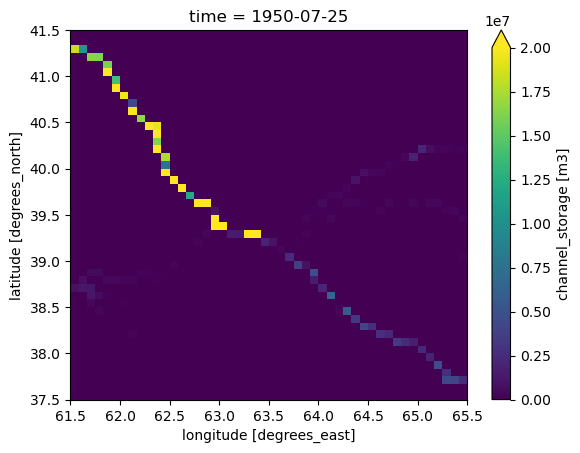

In [17]:


subset_ref = ds_ref["channel_storage"].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # reversed because lat is descending
)

subset_update = ds_update["channel_storage"].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # reversed because lat is descending
)

plt.figure()
subset_ref.sel(time="1950-07-25").plot(vmax=2e7)  # vmax=2000)

plt.figure()
subset_update.sel(time="1950-07-25").plot(vmax=2e7)  # vmax=2000)

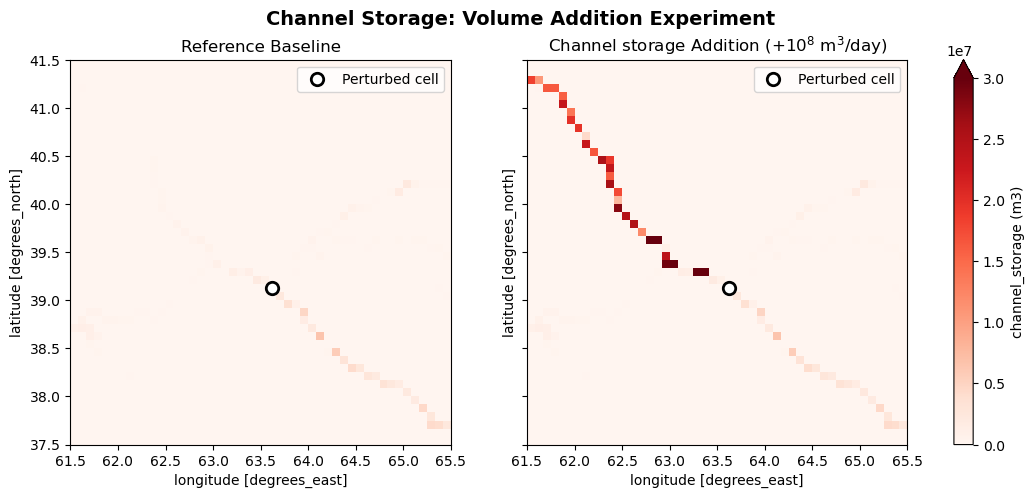

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

vmax = 3e7
vmin = 0

im = subset_ref.sel(time="1950-07-25").plot(
    ax=axes[0], vmin=vmin, vmax=vmax, add_colorbar=False, cmap="Reds"
)
axes[0].set_title("Reference Baseline", fontsize=12)

subset_update.sel(time="1950-07-25").plot(
    ax=axes[1], vmin=vmin, vmax=vmax, add_colorbar=False, cmap="Reds"
)

axes[1].set_title(r"Channel storage Addition ($+10^8\text{ m}^3/\text{day}$)", fontsize=12)

point_lon, point_lat = 63.62, 39.122
for ax in axes:
    #ax.scatter(point_lon, point_lat, color="red", s=60, marker="o", zorder=5)
    #plt.scatter(x, y, marker='o', facecolors='white', edgecolors='black', linewidths=2, s=100)
    ax.scatter(point_lon, point_lat, facecolors="white", edgecolors="black", linewidths=2, s=80, marker="o", zorder=5, label="Perturbed cell")
    ax.legend()
    # The black background "shadow" (slightly thicker line)




cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.05, extend="max")

# ---- Add label manually ----
units = subset_ref.attrs.get("units", "")
name = subset_ref.attrs.get("long_name")
cbar.set_label(f"{name} ({units})")

plt.suptitle("Channel Storage: Volume Addition Experiment",fontsize=14, fontweight="bold", y=0.98)
plt.savefig("channel_storage_experiment_channel_storage_comparison.pdf", bbox_inches="tight", dpi=300)
# plt.tight_layout()
plt.show()

In [19]:
# subset_update

In [20]:
# soil_moisture = reference.get_value_as_xarray("discharge")

# # Copy the field and manually overwrite a random part of the domain
# irrigated_soil_moisture = soil_moisture.copy()
# # irrigated_soil_moisture[100:200, 100:200] += 100

# # Indices of the point
# lat_idx = 61
# lon_idx = 127

# # Add 100 to that specific cell
# irrigated_soil_moisture.values[lat_idx, lon_idx] += 10000000
# print(irrigated_soil_moisture.values[lat_idx, lon_idx])

In [21]:
# lat = 63.5
# lon = 39.1
# value = irrigated_soil_moisture.sel(longitude=lon, latitude=lat, method="nearest")
# print(value)

In [22]:
# lon_idx = int(abs(soil_moisture_safe.longitude - point_lon).argmin().values)

# # Find the index along latitude
# lat_idx = int(abs(soil_moisture_safe.latitude - point_lat).argmin().values)

# print("Index along longitude:", lon_idx)
# print("Index along latitude:", lat_idx)

## Set_value experiments

This section compares a baseline run with a run where `channel_storage` is perturbed after each update.

In [23]:
set_value_start_date = "1949-09-01T00:00:00Z"
set_value_end_date = "1950-12-31T00:00:00Z"

In [ ]:
test_get_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


test_set_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

test_set_multiple_values = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

# test_set_value_before_update = ewatercycle.models.PCRGlobWB(
#     parameter_set=parameter_set_test,
#     forcing=forcing,
#     bmi_image=my_image
# )

In [ ]:
for cfg_dir in [Path("karalkum_experiment_get_value"), Path("karalkum_experiment_set_value"), Path("karalkum_experiment_set_multiple_values")]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

In [ ]:
test_get_value_config, test_get_value_dir = test_get_value.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0, cfg_dir="karalkum_experiment_get_value"
)
test_get_value_config, test_get_value_dir

test_set_value_config, test_set_value_dir = test_set_value.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0, cfg_dir="karalkum_experiment_set_value"
)
test_set_value_config, test_set_value_dir

test_set_multiple_values_config, test_set_multiple_values_dir = test_set_multiple_values.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0, cfg_dir="karalkum_experiment_set_multiple_values"
)
test_set_multiple_values_config, test_set_multiple_values_dir


# test_set_value_before_update_config, test_set_value_before_update_dir = test_set_value_before_update.setup(
#     start_time = set_value_start_date,
#     end_time = set_value_end_date,
#     max_spinups_in_years=0
# )
# test_set_value_before_update_config, test_set_value_before_update_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/irrigation_experiments/karalkum_experiment_set_value/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/irrigation_experiments/karalkum_experiment_set_value')

In [27]:
print(reference.parameters)

test_get_value_para = test_set_value.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(set_value_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(set_value_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-06-01T00:00:00Z'), ('end_time', '1950-07-30T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 486

In [ ]:
test_set_value.initialize(test_set_value_config)
# test_set_value_before_update.initialize(test_set_value_before_update_config)
test_get_value.initialize(test_get_value_config)
test_set_multiple_values.initialize(test_set_multiple_values_config)

In [29]:
lat_idx = 61
lon_idx = 127
m3s = 300
m3day = m3s * 24 * 3600
season_coeff = 2

# make sure it is run once before editing values etc
test_get_value.update()
# test_set_value_before_update.update()
test_set_value.update()


for _ in tqdm(range(number_of_days - 1), desc="Running model"):
    # Convert to datetime
    dt = pd.to_datetime(test_set_value.time_as_isostr)

    # Day of year (1–365/366)
    doy = dt.dayofyear
    season = (1 - np.cos(2 * np.pi * (doy - 1) / 365)) / 2

    # #### Update channel storage before update
    # test_variable_before = test_set_value_before_update.get_value_as_xarray(
    #     "channel_storage",
    # )

    # test_values_before = test_variable_before.values.copy()
    # test_values_before[lat_idx, lon_idx] -=m3day
    # test_set_value_before_update.set_value("channel_storage", test_values_before.flatten())

    #### Timestep
    test_get_value.update()
    # test_set_value_before_update.update()
    test_set_value.update()

    #### Update channel storage after update
    test_variable = test_set_value.get_value_as_xarray(
        "channel_storage",
    )
    test_values = test_variable.values.copy()
    test_values[lat_idx, lon_idx] -= season * season_coeff * m3day
    test_set_value.set_value("channel_storage", test_values.flatten())

    #### Track discharge at station locations
    time = test_set_value.time_as_isostr

    for station_name, coords in STATIONS_PCR.items():
        discharge_getvalue = test_get_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        channel_storage_getvalue = test_get_value.get_value_at_coords(
            "channel_storage",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        discharge_setvalue = test_set_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        channel_storage_setvalue = test_set_value.get_value_at_coords(
            "channel_storage",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        # discharge_setvalue_before = test_set_value_before_update.get_value_at_coords(
        #     "discharge",
        #     lat=[coords["lat"]],
        #     lon=[coords["lon"]],
        # )

        # channel_storage_setvalue_before_update = test_set_value_before_update.get_value_at_coords(
        #     "channel_storage",
        #     lat=[coords["lat"]],
        #     lon=[coords["lon"]],
        # )

        stations_timeseries_getvalue.loc[time, station_name] = discharge_getvalue[0]
        stations_timeseries_setvalue.loc[time, station_name] = discharge_setvalue[0]
        # stations_timeseries_setvalue_before.loc[time, station_name] = discharge_setvalue_before[0]

        channel_storage_getvalue_series.loc[time, station_name] = channel_storage_getvalue[0]
        # channel_storage_setvalue_before_update_series.loc[time, station_name] = channel_storage_setvalue_before_update[0]
        channel_storage_setvalue_series.loc[time, station_name] = channel_storage_setvalue[0]


print("Model run finished!")

Running model:   0%|          | 0/485 [00:00<?, ?it/s]

Model run finished!

In [30]:
grdc_station_id = "2817100"
data_home = GRDC / "Daily"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time="1900-01-01T00:00:00Z",  # or: model_instance.start_time_as_isostr
    end_time="1990-12-15T00:00:00Z",
    data_home=data_home,
)
observations

Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

In [41]:
stations_timeseries_getvalue.sort_values(by="time", inplace=True)
stations_timeseries_setvalue.sort_values(by="time", inplace=True)

<Axes: xlabel='time'>

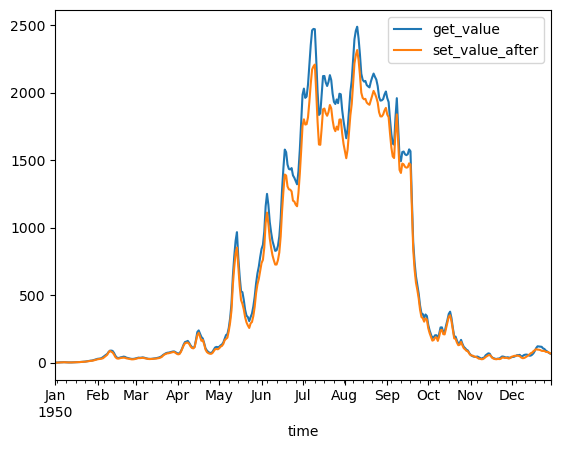

In [42]:
combined = pd.concat(
    [
        stations_timeseries_getvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "get_value"}
        ),
        stations_timeseries_setvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "set_value_after"}
        ),
        # stations_timeseries_setvalue_before.loc["1950", ["Chatly"]].rename(columns={"Chatly": "set_value_before"}),
    ],
    axis=1,
)

combined.plot()

<function matplotlib.pyplot.show(close=None, block=None)>

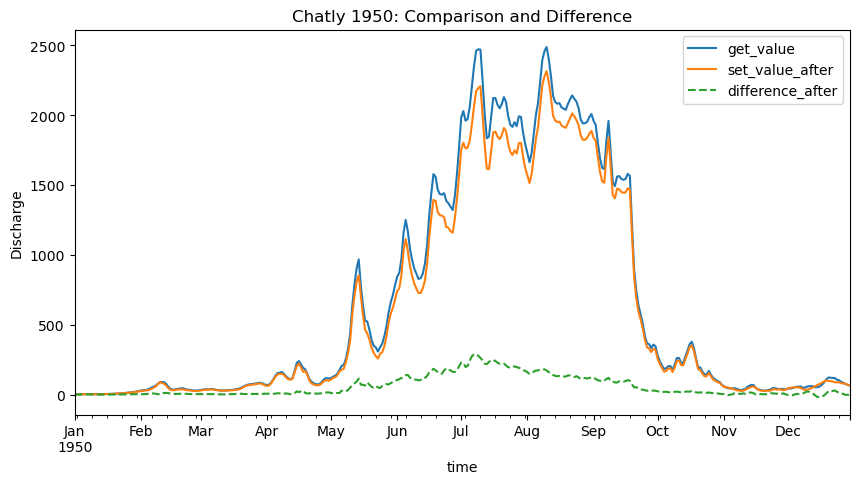

In [43]:
combined["difference_after"] = combined["get_value"] - combined["set_value_after"]

# Plot
ax = combined[["get_value", "set_value_after"]].plot(
    figsize=(10, 5), label=["get_value", "set_value_after"]
)
combined[["difference_after"]].plot(ax=ax, style="--", label=["difference_after"])

ax.set_ylabel("Discharge")
ax.set_title("Chatly 1950: Comparison and Difference")
ax.legend()
plt.show

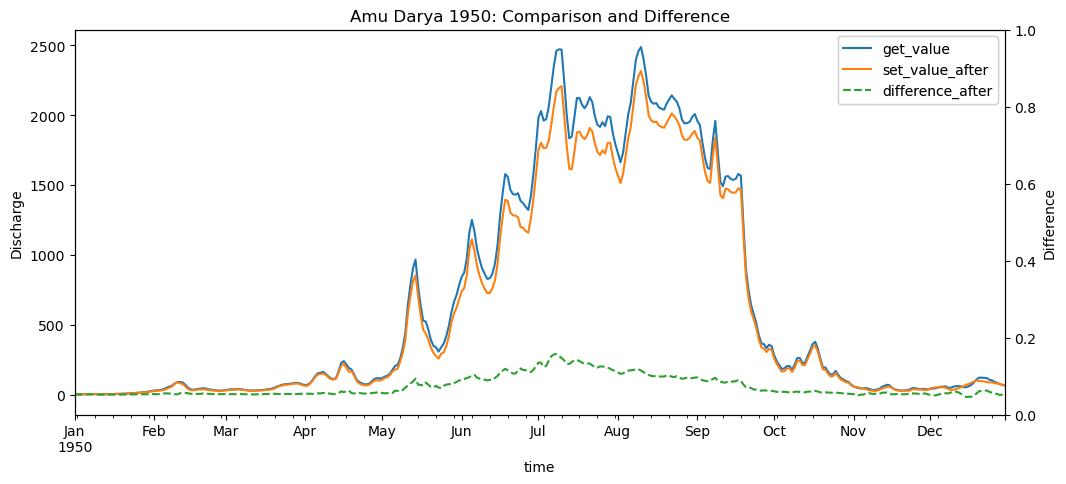

In [44]:
# Create main plot for get_value and set_value
fig, ax = plt.subplots(figsize=(12, 5))
combined[["get_value", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")
ax.grid()

# Plot difference on secondary y-axis
ax2 = ax.twinx()
combined[["difference_after"]].plot(ax=ax, style="--", label=["difference_after"])
ax2.set_ylabel("Difference")

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")


plt.show()

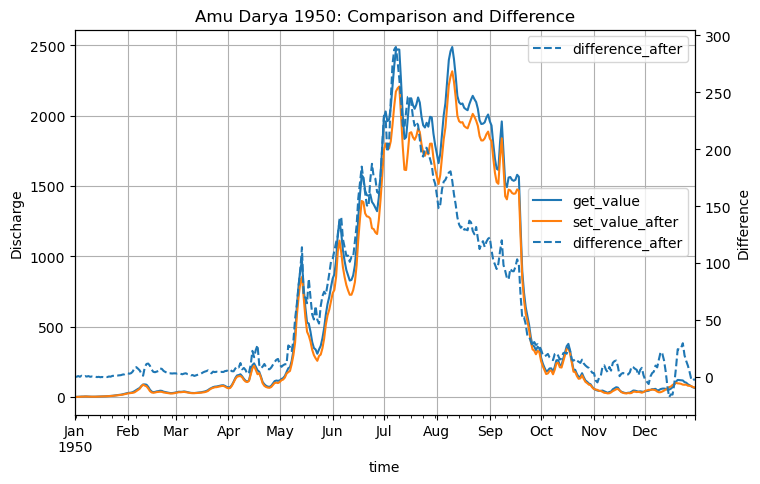

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
combined[["get_value", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")

ax.grid(True)
ax2 = ax.twinx()

combined[["difference_after"]].plot(
    ax=ax2, style="--"
)  # , label=["difference_before","difference_after"])
ax2.set_ylabel("Difference")

# Disable grid on second axis
ax2.grid(False)

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="center right")

plt.show()

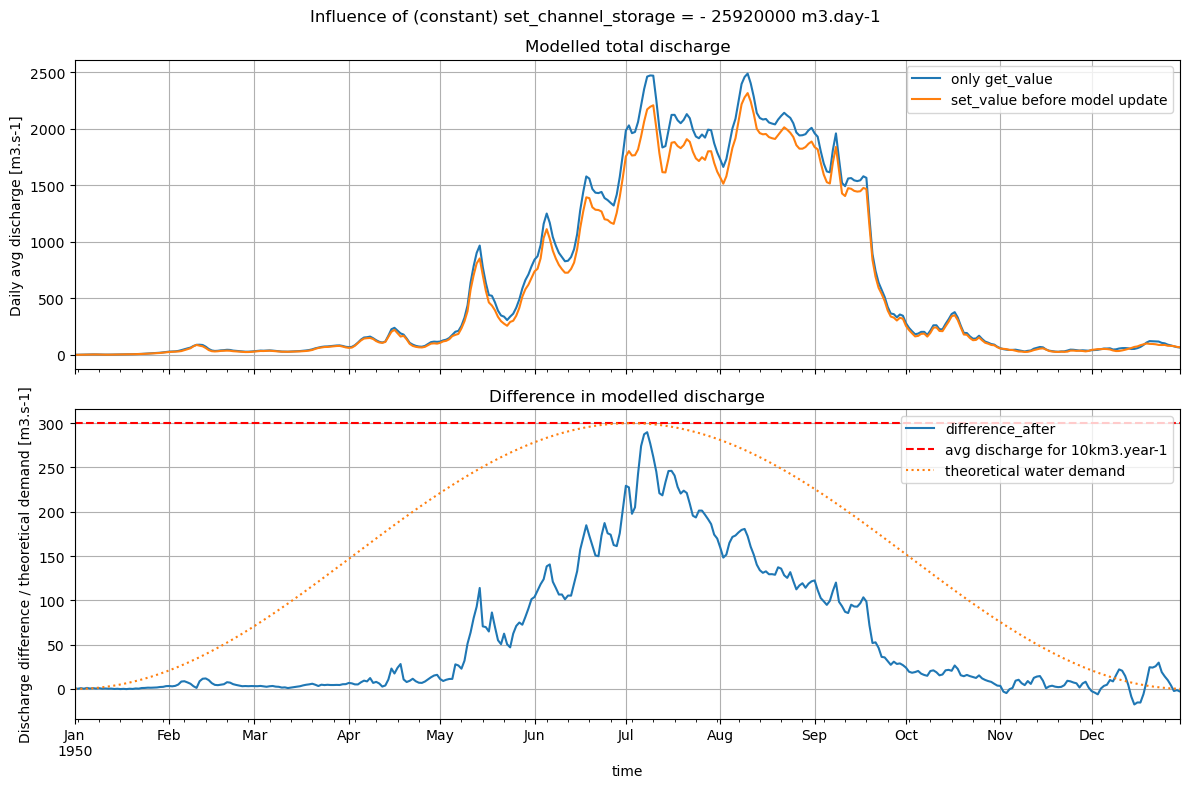

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

combined[["get_value", "set_value_after"]].plot(ax=ax1)
ax1.set_ylabel("Daily avg discharge [m3.s-1]")
ax1.grid(True)
ax1.legend(["only get_value", "set_value before model update"])
ax1.set_title("Modelled total discharge")

combined[["difference_after"]].plot(ax=ax2, style="-", label=["difference_after"])
ax2.axhline(y=300, linestyle="--", color="red", label="avg discharge for 10km3.year-1")
ax2.set_ylabel("Discharge difference [m3.s-1]")
ax2.grid(True)
ax2.set_title("Difference in modelled discharge")

time_index = pd.to_datetime(combined.index)
season = (1 - np.cos(2 * np.pi * (time_index.dayofyear - 1) / 365)) / 2
theoretical_water_demand = season  * m3day / 86400
ax2.plot(
    combined.index,
    theoretical_water_demand,
    color="tab:orange",
    linestyle=":",
    label="theoretical water demand",
)
ax2.set_ylabel("Discharge difference / theoretical demand [m3.s-1]")

lines_1, labels_1 = ax2.get_legend_handles_labels()
ax2.legend(lines_1, labels_1, loc="upper right")

plt.suptitle(f"Influence of (constant) set_channel_storage = - {m3day} m3.day-1")
plt.tight_layout()
plt.show()

In [46]:
combined.to_pickle("channel_storage_experiment_timeseries.pkl")
stations_timeseries_getvalue.to_pickle("stations_timeseries_getvalue.pkl")
stations_timeseries_setvalue.to_pickle("stations_timeseries_setvalue.pkl")

## Observation comparison

This section compares the simulated time series against GRDC-derived observations.

In [ ]:
# get_value_experiment_start_date = "1949-06-01T00:00:00Z"
# get_value_experiment_end_date = "1950-12-31T00:00:00Z"

In [ ]:
# test_get_value = ewatercycle.models.PCRGlobWB(
#     parameter_set=parameter_set_test,
#     forcing=forcing,
#     bmi_image=my_image
# )


In [ ]:
# test_get_value_config, test_get_value_dir = test_get_value.setup(
#     start_time = get_value_experiment_start_date,
#     end_time = get_value_experiment_end_date,
#     max_spinups_in_years=0
# )
# test_get_value_config, test_get_value_dir

In [ ]:
# print(reference.parameters)

# test_get_value_para = test_get_value.parameters

# # Convert ISO 8601 strings to datetime objects
# start_time = datetime.strptime(get_value_experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
# end_time = datetime.strptime(get_value_experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')

# # Calculate the number of days for the progression bar
# delta = end_time - start_time
# number_of_days = delta.days
# print(f"Number of days to model: {number_of_days}")

In [ ]:
# test_get_value.initialize(test_get_value_config)

In [ ]:
# for _ in tqdm(range(number_of_days), desc="Running model"):

#     test_get_value.update()

#     #Track discharge at station locations
#     time = test_get_value.time_as_isostr

#     for station_name, coords in STATIONS_PCR.items():

#         discharge = test_get_value.get_value_at_coords(
#             "discharge",
#             lat=[coords["lat"]],
#             lon=[coords["lon"]],
#         )

#         stations_timeseries_getvalue.loc[time, station_name] = discharge[0]

#     # test_values = test_get_value.get_value("discharge")
#     # print(f"max = {np.max(test_values)}")

# #     discharge_at_station = test_get_value.get_value_at_coords(
# #     "discharge",
# #     lat=[lat],
# #     lon=[lon]
# # )


# # print(type(test_values))
# print("Model run finished!")

# #print(type(discharge_at_Chatly))

In [ ]:
grdc_station_id = "2817100"
data_home = GRDC / "Daily"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time="1900-01-01T00:00:00Z",  # or: model_instance.start_time_as_isostr
    end_time="1990-12-15T00:00:00Z",
    data_home=data_home,
)
observations

In [ ]:
Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

In [ ]:
# stations_timeseries_getvalue.loc["1950"][["Karaozek"]].plot(label = "get_value")
# stations_timeseries_setvalue.loc["1950"][["Karaozek"]].plot(label = "set_value")

# #stations_timeseries_getvalue.loc["1950"][["Kerki","Chatly"]].plot()


# #observations.sel(time="1950")["streamflow"].plot(label = "GRDC-Chatly")
# plt.legend()
# #stations_timeseries.plot()

In [ ]:
combined = pd.concat(
    [
        stations_timeseries_getvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "get_value"}
        ),
        stations_timeseries_setvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "set_value_after"}
        ),
        # stations_timeseries_setvalue_before.loc["1950", ["Chatly"]].rename(columns={"Chatly": "set_value_before"}),
    ],
    axis=1,
)

combined.plot()

In [ ]:
# Compute difference: get_value - set_value

# combined["difference_before"] = combined["get_value"] - combined["set_value_before"]
combined["difference_after"] = combined["get_value"] - combined["set_value_after"]

# Plot
ax = combined[["get_value", "set_value_after"]].plot(
    figsize=(10, 5), label=["get_value", "set_value_after"]
)
combined[["difference_after"]].plot(ax=ax, style="--", label=["difference_after"])

ax.set_ylabel("Discharge")
ax.set_title("Chatly 1950: Comparison and Difference")
ax.legend()
plt.show

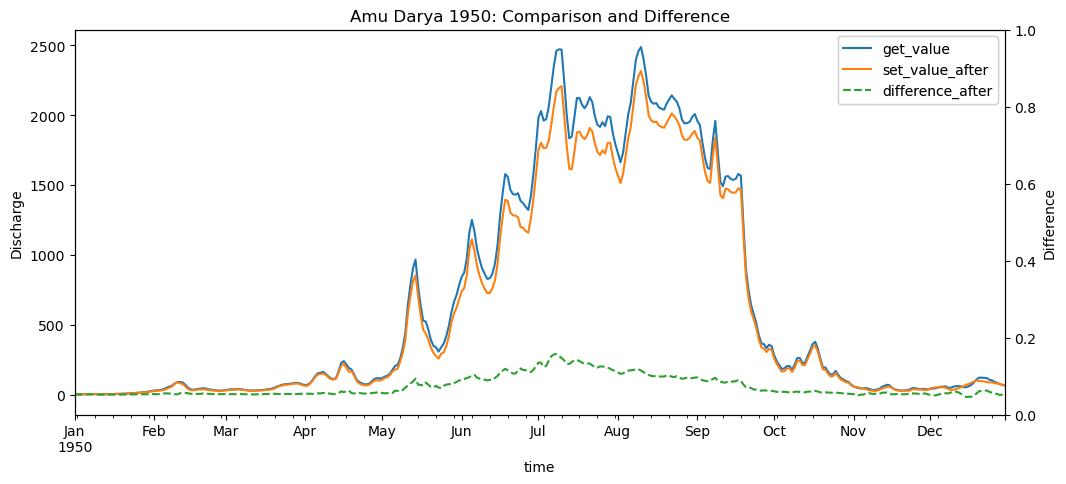

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# # Combine the two series for 1950
# combined = pd.concat([
#     stations_timeseries_getvalue.loc["1950", ["Chatly"]].rename(columns={"Chatly": "get_value"}),
#     stations_timeseries_setvalue.loc["1950", ["Chatly"]].rename(columns={"Chatly": "set_value"})
# ], axis=1)


# Create main plot for get_value and set_value
fig, ax = plt.subplots(figsize=(12, 5))
combined[["get_value", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")
ax.grid()

# Plot difference on secondary y-axis
ax2 = ax.twinx()
combined[["difference_after"]].plot(ax=ax, style="--", label=["difference_after"])
ax2.set_ylabel("Difference")

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")


plt.show()

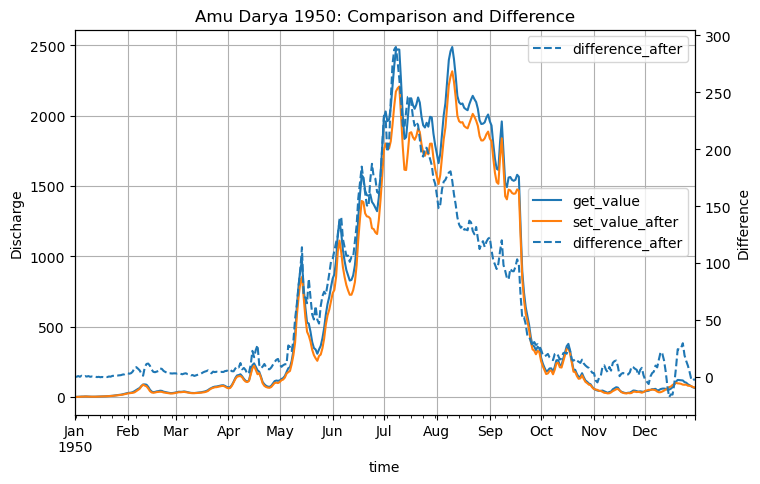

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
combined[["get_value", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")

ax.grid(True)
ax2 = ax.twinx()

combined[["difference_after"]].plot(
    ax=ax2, style="--"
)  # , label=["difference_before","difference_after"])
ax2.set_ylabel("Difference")

# Disable grid on second axis
ax2.grid(False)

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="center right")

plt.show()

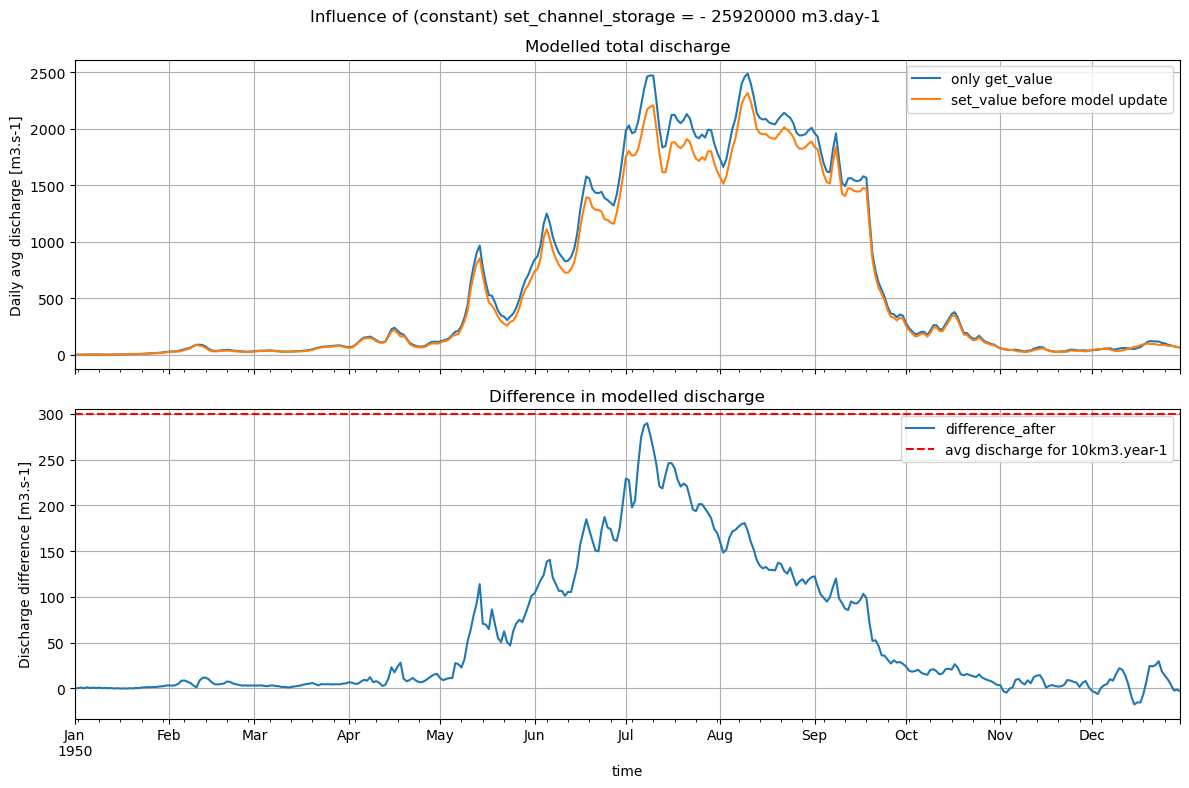

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

combined[["get_value", "set_value_after"]].plot(ax=ax1)
ax1.set_ylabel("Daily avg discharge [m3.s-1]")
ax1.grid(True)
ax1.legend(["only get_value", "set_value before model update"])
ax1.set_title("Modelled total discharge")

combined[["difference_after"]].plot(ax=ax2, style="-", label=["difference_after"])
ax2.axhline(y=300, linestyle="--", color="red", label="avg discharge for 10km3.year-1")
ax2.set_ylabel("Discharge difference [m3.s-1]")
ax2.grid(True)
ax2.legend()
ax2.set_title("Difference in modelled discharge")

plt.suptitle(f"Influence of (constant) set_channel_storage = - {m3day} m3.day-1")
plt.tight_layout()
plt.show()

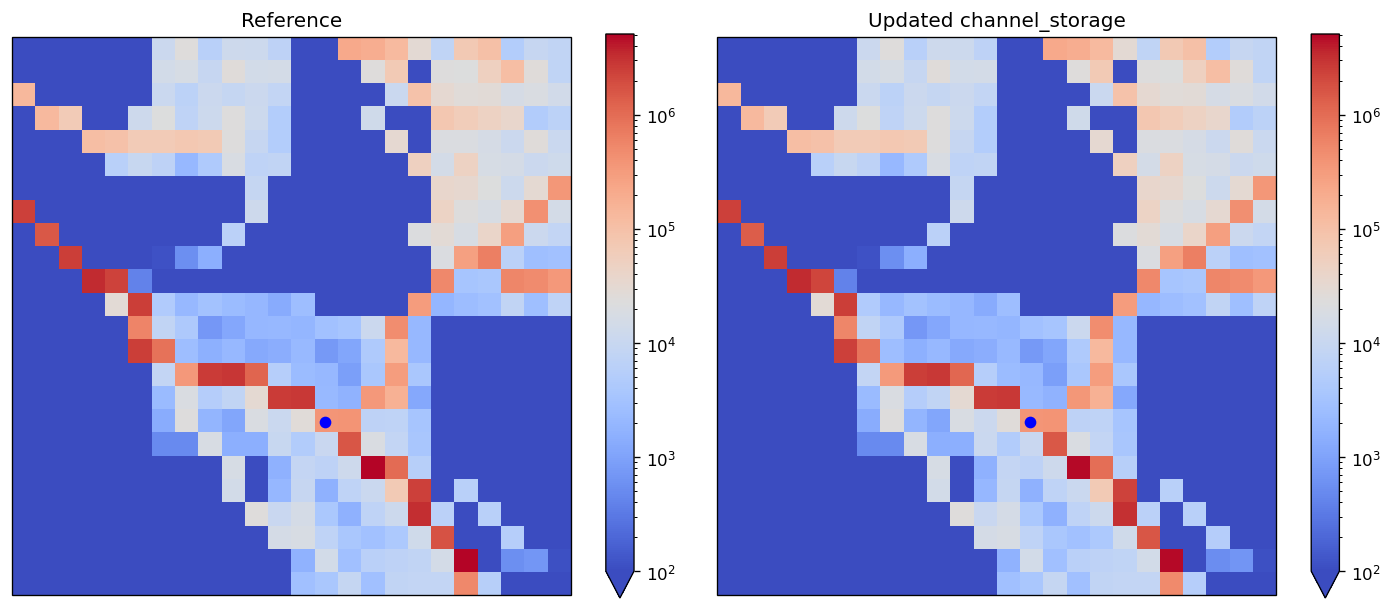

In [51]:
discharge_getvalue_plot = test_get_value.get_value_as_xarray("channel_storage")
discharge_setvalue_plot = test_set_value.get_value_as_xarray("channel_storage")


# -----------------------------
# Replace non-positive values
# -----------------------------
discharge_getvalue_plot_safe = discharge_getvalue_plot.where(discharge_getvalue_plot > 0, 1e-6)
discharge_setvalue_plot_safe = discharge_setvalue_plot.where(discharge_setvalue_plot > 0, 1e-6)

# Swap coordinates names
discharge_getvalue_plot_safe = discharge_getvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

discharge_setvalue_plot_safe = discharge_setvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

vmin_plot = 100
# -----------------------------
# Define zoom box (lon/lat)
# -----------------------------
lon_min, lon_max = 62.5, 64.5
lat_min, lat_max = 38.5, 40.5

# Ensure correct slicing even if coordinates are descending
lat0, lat1 = sorted([lat_min, lat_max])
lon0, lon1 = sorted([lon_min, lon_max])

get_value_subset = discharge_getvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

set_value_subset = discharge_setvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

# -----------------------------
# Set up figure
# -----------------------------
fig = plt.figure(figsize=(12, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=ccrs.PlateCarree())
right_axes = fig.add_subplot(122, projection=ccrs.PlateCarree())

# -----------------------------
# Plot the subsets
# -----------------------------
get_value_subset.plot(
    ax=left_axes,
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max()),
)

set_value_subset.plot(
    ax=right_axes,
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max()),
)

# -----------------------------
# Decorations
# -----------------------------
left_axes.set_title("Reference")
right_axes.set_title("Updated channel_storage")

for ax in [left_axes, right_axes]:
    ax.add_feature(cfeature.OCEAN, zorder=2)
    ax.coastlines(zorder=3)

# -----------------------------
# Plot a point
# -----------------------------
point_lon, point_lat = 63.62, 39.122
for ax in [left_axes, right_axes]:
    ax.plot(
        point_lon, point_lat, color="blue", linewidth=2, marker="o", transform=ccrs.PlateCarree()
    )

plt.tight_layout()
plt.show()

In [52]:
reference.finalize()
reference_2x.finalize()
test_get_value.finalize()
test_set_value.finalize()
# test_set_value_before_update.finalize()